In [6]:
import numpy as np

In [7]:
data = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'],
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]


In [8]:
data = np.array(data)

In [9]:
convert = {'Apple':0, "Banana":1, "Orange":2}
X_train = data[:, :3].astype(float)
y_train = [convert[p] for p in data[:, 3]]
y_train = np.array(y_train)

In [10]:
print(X_train, y_train)

[[150.    7.    1. ]
 [120.    6.5   0. ]
 [180.    7.5   2. ]
 [155.    7.2   1. ]
 [110.    6.    0. ]
 [190.    7.8   2. ]
 [145.    7.1   1. ]
 [115.    6.3   0. ]] [0 1 2 0 1 2 0 1]


In [12]:
# OneHotEncoding from scratch
data1 = [
    [150, 7.0, 1, 'Apple'],
    [120, 6.5, 0, 'Banana'],
    [180, 7.5, 2, 'Orange'],
    [155, 7.2, 1, 'Apple'],
    [110, 6.0, 0, 'Banana'],
    [190, 7.8, 2, 'Orange'],
    [145, 7.1, 1, 'Apple'],
    [115, 6.3, 0, 'Banana']
]
names = [row[3] for row in data1]
unique_label = sorted(set(names))

label_index = {lable: i for i, lable in enumerate(unique_label)}
# print(label_index)
n = len(names)
p = len(unique_label)

new_data = np.zeros((n, p))

for i, label in enumerate(names):
    idx = label_index[label]
    new_data[i][idx] = 1
print(label_index)
print(new_data)


{'Apple': 0, 'Banana': 1, 'Orange': 2}
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [13]:
# droping one column for avoiding dummy variable traps
new_data_onehot_droped = new_data[:, 1:]
new_data_onehot_droped

# no need in KNN although

array([[0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.]])

In [14]:
# step 2 : euclidean distance function

def euclidean_distance(x1, x2):
    x = 0
    for i in range(len(x1)):
        x += (x1[i] - x2[i])**2
    return np.sqrt(x)



In [15]:
# step 3:
class KNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict_one(self, x):
        dis = []
        for i in range(len(self.X_train)):
            dist = euclidean_distance(x, self.X_train[i])
            dis.append((dist, self.y_train[i]))

        dis.sort(key=lambda p: p[0])
        first_k = dis[:self.k]
        freq = {}
        for _, i in first_k:
            if i in freq:
                freq[i] += 1
            else:
                freq[i] = 1
        mex = -1
        ans = 0
        for _ in freq:
            if freq[_] > mex:
                mex = freq[_]
                ans = _
        return ans


    def predict(self, X_test):
        x_test = np.array(X_test)
        pred = []

        for x in x_test:
            p = self.predict_one(x)
            pred.append(p)
        prediction = np.array(pred)
        return prediction

In [16]:
# testing (step 4)

In [17]:
test_data = np.array([
    [118, 6.2, 0],  # Expected: Banana
    [160, 7.3, 1],  # Expected: Apple
    [185, 7.7, 2]   # Expected: Orange
])

# for my dataset 0-> apple 1-> banana 2-> orange
tranform = {0:1, 1:0, 2:2}
for _ in test_data:
    _[2] = tranform[_[2]]
test_data

array([[118. ,   6.2,   1. ],
       [160. ,   7.3,   0. ],
       [185. ,   7.7,   2. ]])

In [18]:
model = KNN(k=3)

In [19]:
model.fit(X_train, y_train)

In [20]:
prediction = model.predict(test_data)

In [21]:

for _ in prediction:
    _ = tranform[_]
# now the prediction answer is based on the data as per give
print(prediction)   #

[1 0 2]


In [22]:
# step 5: evaluating
def work(k, X_train, y_train, test_data):
    model = KNN(k=k)
    model.fit(X_train, y_train)
    prediction = model.predict(test_data)
    for _ in prediction:
        _ = tranform[_]
    print(prediction)

In [23]:
work(k=5, X_train=X_train, y_train=y_train, test_data=test_data)
work(k=3, X_train=X_train, y_train=y_train, test_data=test_data)
work(k=1, X_train=X_train, y_train=y_train, test_data=test_data)

[1 0 0]
[1 0 2]
[1 0 2]


In [24]:
# Bonus challanges

# 1. Implement a simple accuracy checker if true labels are known
# accu = (correct prediction/total prediction)

def accuracy(y_pred, y_true):
    corr = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i]:
            corr+=1

    ans = corr/len(y_pred)
    return ans


In [25]:
# 2. Normalize your features using min-max or z-score normalization
# I will used Z_score normalisation

# z = (x - mu)/std
def z_score_normalisation(x):
    X = np.array(x, dtype=float)
    std = np.std(X, axis=0)
    X_norm = (X - np.mean(X, axis=0)) / std
    return X_norm

# work(k=3, X_train=z_score_normalisation(X_train), y_train=z_score_normalisation(y_train), test_data=test_data)


In [26]:
# Add a basic train-test split (e.g., 70-30 or 80-20)
# we split using np.randoms 70-30 percent usually whant i used regullary on kaggle or personal projects

def train_test_split(X, y, random_state=None):
    X = np.array(X)
    y = np.array(y)
    if random_state is not None:
        np.random.seed(random_state)

    # suffling
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    test_size = 0.3

    split_idx = int(len(X)*(1-test_size))
    train_idx = idx[:split_idx]
    test_idx = idx[split_idx:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, y_train, X_test, y_test




In [27]:
# Try different distance metrics like Manhattan or Minkowski

# step 3:
class KNN:
    def __init__(self, k=3, p = 2,  metric='euclidean'):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.metric = metric
        self.p = p

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def distance(self, p1, p2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((p1-p2)**2))

        elif self.metric == 'manhattan':
            return np.sum(np.abs(p1-p2))

        elif self.metric == 'minkowski':
            return np.sum(np.abs(p1-p2)**self.p)**(1 / self.p)


    def predict_one(self, x):
        dis = []
        for i in range(len(self.X_train)):
            dist = self.distance(x, self.X_train[i])
            dis.append((dist, self.y_train[i]))

        dis.sort(key=lambda p: p[0])
        first_k = dis[:self.k]
        freq = {}
        for _, i in first_k:
            if i in freq:
                freq[i] += 1
            else:
                freq[i] = 1
        mex = -1
        ans = 0
        for _ in freq:
            if freq[_] > mex:
                mex = freq[_]
                ans = _
        return ans


    def predict(self, X_test):
        x_test = np.array(X_test)
        pred = []

        for x in x_test:
            p = self.predict_one(x)
            pred.append(p)
        prediction = np.array(pred)
        return prediction

In [28]:
test_model = KNN(p=3, metric='minkowski')
test_model.fit(X_train, y_train)
test_model.predict(test_data)

array([1, 0, 2])

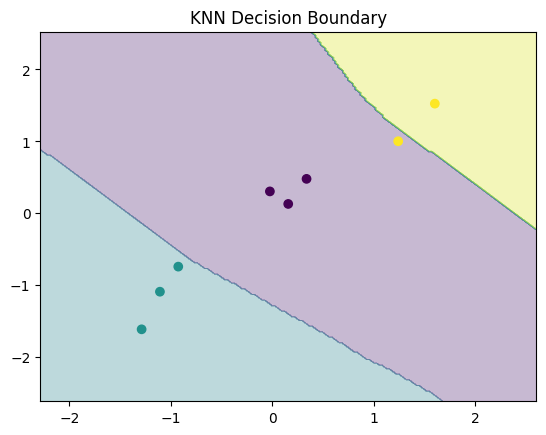

In [31]:
# visualising
# Visualize the decision boundaries in 2D using matplotlib

import matplotlib.pyplot as plt
X_vis = z_score_normalisation(X_train)
vis_model = KNN(k=3)
vis_model.fit(X_vis, y_train)

x_min = X_vis[:, 0].min() - 1
x_max = X_vis[:, 0].max() + 1
y_min = X_vis[:, 1].min() - 1
y_max = X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

z_fixed = np.mean(X_vis[:, 2])

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, z_fixed)]
Z = vis_model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train)
plt.title("KNN Decision Boundary")
plt.show()
